In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import ast

In [9]:
import seaborn as sns

In [2]:
# 1. Define the base directory generically
DATA_DIR = Path('C:/Users/iamph/OneDrive/Documents/Datasets/Kaggle_Fitness_Workout_Dataset')

# 2. Safely join the path to the file
file_path = DATA_DIR / 'program_summary_CLEAN_260728.csv'

df = pd.read_csv(file_path)

In [3]:
# 2. Safely join the path to the file
file_path = DATA_DIR / 'programs_detailed_boostcamp_kaggle_260812_day_label.csv'

ex = pd.read_csv(file_path)

# Clean Datasets

In [5]:
df.dtypes

title                       str
description                 str
level                       str
goal                        str
equipment                   str
program_length_weeks      int64
time_per_workout          int64
total_exercises           int64
program_length_days       int64
average_intensity       float64
dtype: object

In [4]:
df['level'] = df['level'].apply(ast.literal_eval)
df['goal'] = df['goal'].apply(ast.literal_eval)
df.level = df.level.apply(set)
df.goal = df.goal.apply(set)

In [8]:
df.level.value_counts()

level
{Advanced, Novice, Beginner, Intermediate}    310
{Novice, Beginner, Intermediate}              204
{Novice, Intermediate}                        193
{Advanced, Intermediate}                      173
{Advanced, Novice, Intermediate}              158
{Intermediate}                                158
{Novice, Beginner}                             56
{Novice}                                       46
{Beginner}                                     31
{Advanced}                                     31
Name: count, dtype: int64

In [5]:
ex['level'] = ex['level'].apply(ast.literal_eval)
ex['goal'] = ex['goal'].apply(ast.literal_eval)
ex.level = ex.level.apply(set)
ex.goal = ex.goal.apply(set)

In [11]:
ex.head()

,title,description,level,goal,equipment,program_length,time_per_workout,week,day,number_of_exercises,exercise_name,sets,reps,intensity,exercise_label
0,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{Advanced, Beginner, Intermediate}","{Bodybuilding, Powerbuilding}",Full Gym,7,90,1,1,4,Squat (Barbell),1,15,8,Legs
1,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{Advanced, Beginner, Intermediate}","{Bodybuilding, Powerbuilding}",Full Gym,7,90,1,1,4,Leg Press (45 Degrees),1,100,9,Legs
2,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{Advanced, Beginner, Intermediate}","{Bodybuilding, Powerbuilding}",Full Gym,7,90,1,1,4,Leg Extension,4,5,9,Legs
3,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{Advanced, Beginner, Intermediate}","{Bodybuilding, Powerbuilding}",Full Gym,7,90,1,1,4,Preacher Curl (Barbell),1,10,9,Arms
4,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{Advanced, Beginner, Intermediate}","{Bodybuilding, Powerbuilding}",Full Gym,7,90,1,2,4,Bent Over Row (Barbell),1,15,9,Back


In [7]:
ex[ex.title == 'nSuns_Rebuild by KSI'].reps.value_counts()


reps
10     36
100    32
5      31
15     26
12      9
7       3
14      2
18      1
Name: count, dtype: int64

# General Statistics

In [7]:
df.shape

(1360, 10)

In [8]:
ex.shape

(261897, 16)

## Level

In [8]:
df.level.value_counts()

level
{Beginner, Advanced, Intermediate, Novice}    310
{Beginner, Intermediate, Novice}              204
{Intermediate, Novice}                        193
{Advanced, Intermediate}                      173
{Advanced, Intermediate, Novice}              158
{Intermediate}                                158
{Beginner, Novice}                             56
{Novice}                                       46
{Beginner}                                     31
{Advanced}                                     31
Name: count, dtype: int64

In [50]:
tmp = df.level.value_counts()

In [51]:
tmp.to_csv('test.csv')

In [9]:
df['level'].explode().value_counts()

level
Intermediate    1196
Novice           967
Advanced         672
Beginner         601
Name: count, dtype: int64

<Axes: xlabel='level'>

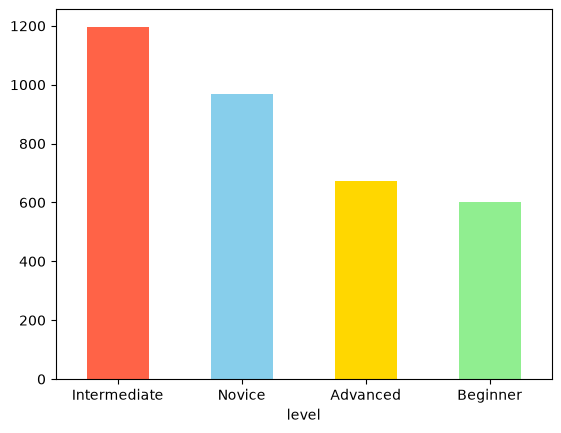

In [16]:
bar_colors = ["tomato", "skyblue", "gold", "lightgreen"]
df['level'].explode().value_counts().plot.bar(color=bar_colors, rot = 0)

## Goal

In [17]:
df.goal.value_counts() 

goal
{Bodybuilding}                                                                                       155
{Bodybuilding, Muscle & Sculpting}                                                                   138
{Bodybuilding, Powerlifting, Powerbuilding}                                                           96
{Bodybuilding, Powerbuilding}                                                                         88
{Bodybuilding, Powerbuilding, Muscle & Sculpting}                                                     80
                                                                                                    ... 
{Powerlifting, Bodyweight Fitness}                                                                     1
{Bodybuilding, Bodyweight Fitness, Olympic Weightlifting}                                              1
{Bodybuilding, Powerbuilding, Olympic Weightlifting, Athletics, Powerlifting, Muscle & Sculpting}      1
{Powerlifting, Bodyweight Fitness, Muscle & Sculpt

In [18]:
df['goal'].explode().value_counts()

goal
Bodybuilding             1132
Powerbuilding             715
Muscle & Sculpting        691
Athletics                 483
Powerlifting              467
Bodyweight Fitness        258
Olympic Weightlifting      48
Name: count, dtype: int64

<Axes: xlabel='goal'>

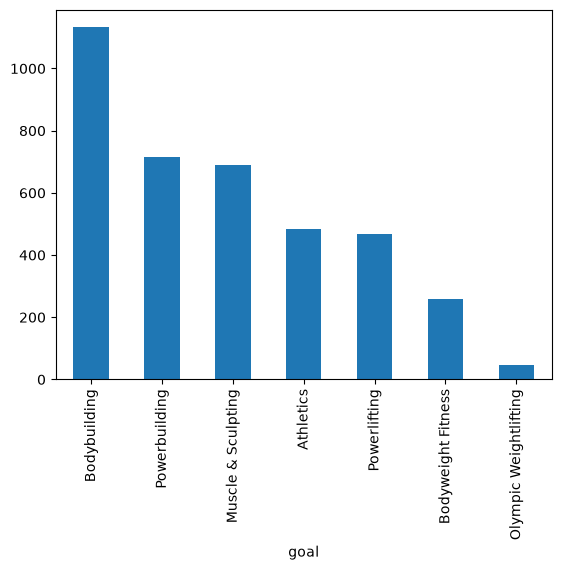

In [20]:
df['goal'].explode().value_counts().plot.bar()

## Equipment

In [21]:
df.equipment.value_counts() 

equipment
Full Gym         929
Garage Gym       333
At Home           68
Dumbbell Only     30
Name: count, dtype: int64

## Time Per workout

In [22]:
df.time_per_workout.value_counts()

time_per_workout
60     420
90     225
70     176
80     119
40     103
50      99
120     67
30      54
100     39
20      23
10      18
180      5
110      5
160      2
140      2
150      1
130      1
170      1
Name: count, dtype: int64

<Axes: xlabel='time_per_workout'>

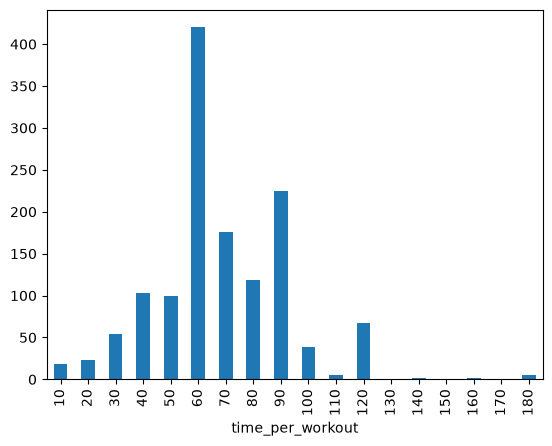

In [23]:
df.time_per_workout.value_counts().sort_index().plot.bar()

## Weeks

In [25]:
df.program_length_weeks.value_counts().sort_index()

program_length_weeks
1      73
2       9
3      49
4     215
5      60
6     149
7      20
8     215
9      35
10     57
11      4
12    372
13      8
14      5
15      7
16     54
17      1
18     27
Name: count, dtype: int64

<Axes: xlabel='program_length_weeks'>

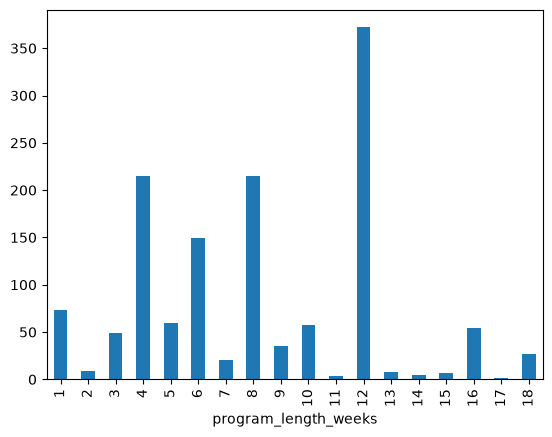

In [24]:
df.program_length_weeks.value_counts().sort_index().plot.bar()

## Days

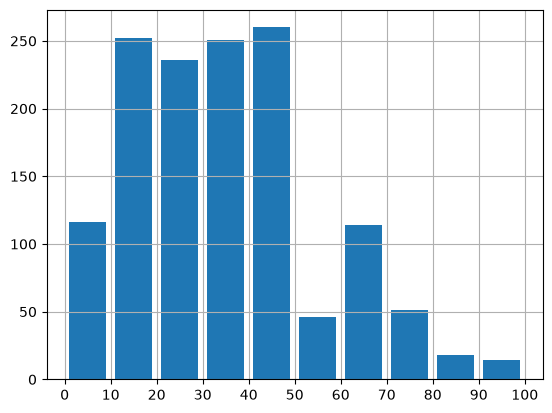

In [26]:
custom_bins = np.arange(0,110,10)
ax = df.program_length_days.hist(bins = custom_bins, rwidth = 0.8)
ax.set_xticks(custom_bins)

## Average Intensity

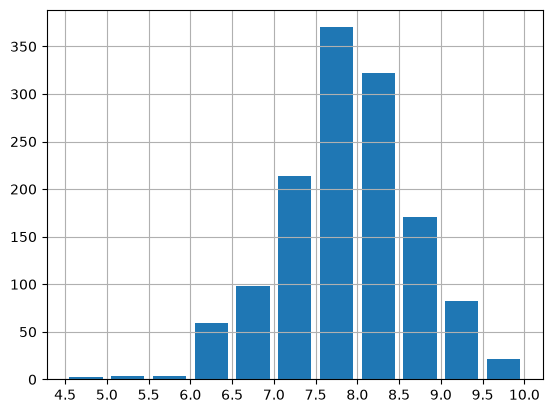

In [27]:
custom_bins = np.arange(4.5,10.5, 0.5)
ax = df.average_intensity.hist(bins = custom_bins, rwidth = 0.8)
ax.set_xticks(custom_bins)

## Average Days per week

In [28]:
df['avg_days_per_week'] = df['program_length_days'] / df['program_length_weeks']

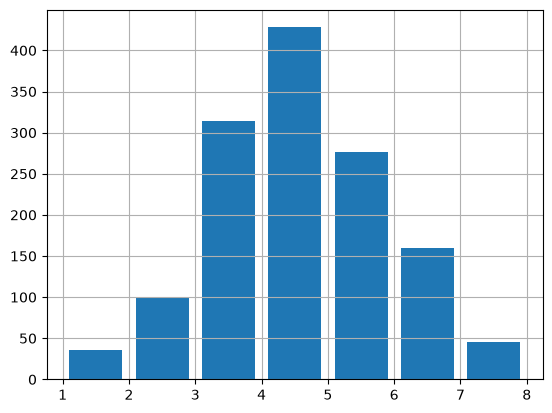

In [29]:
custom_bins = np.arange(1,9)
ax = df.avg_days_per_week.hist(bins = custom_bins, rwidth = 0.8)
ax.set_xticks(custom_bins)

In [30]:
df[df.avg_days_per_week >= 7].shape

(46, 11)

In [31]:
df[df.avg_days_per_week == 7].shape

(46, 11)

## Analyse Workout day type
Cleaning of the sheet was completed add_the_labels_to_exercise_dataset.ipynb

In [33]:
ex.head()

,title,description,level,goal,equipment,program_length,time_per_workout,week,day,number_of_exercises,exercise_name,sets,reps,intensity,exercise_label
0,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{Intermediate, Advanced, Beginner}","{Bodybuilding, Powerbuilding}",Full Gym,7,90,1,1,4,Squat (Barbell),1,15,8,Legs
1,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{Intermediate, Advanced, Beginner}","{Bodybuilding, Powerbuilding}",Full Gym,7,90,1,1,4,Leg Press (45 Degrees),1,100,9,Legs
2,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{Intermediate, Advanced, Beginner}","{Bodybuilding, Powerbuilding}",Full Gym,7,90,1,1,4,Leg Extension,4,5,9,Legs
3,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{Intermediate, Advanced, Beginner}","{Bodybuilding, Powerbuilding}",Full Gym,7,90,1,1,4,Preacher Curl (Barbell),1,10,9,Arms
4,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{Intermediate, Advanced, Beginner}","{Bodybuilding, Powerbuilding}",Full Gym,7,90,1,2,4,Bent Over Row (Barbell),1,15,9,Back


In [68]:
ex2 = ex.copy(deep = True)

In [69]:
ex2.drop_duplicates(subset=['title','week','day'], inplace = True)

In [70]:
ex2['day_label'] = ex2['day_label'].str.split(", ")

In [72]:
ex2['day_label'] = ex2['day_label'].apply(set)

In [59]:
ex.shape

(261897, 16)

In [60]:
ex2.shape

(46154, 16)

In [73]:
ex2.day_label.value_counts()

day_label
{Legs}                                               16346
{Back}                                                5139
{Arms}                                                4903
{Chest}                                               4051
{Shoulders/Neck}                                      2295
                                                     ...  
{Stretching, Back, Abs/Core}                             2
{Stretching, Cardio/Plyos, Shoulders/Neck, Chest}        1
{Cardio/Plyos, Chest, Stretching, Legs, Back}            1
{Stretching, Abs/Core, Legs}                             1
{Back, Abs/Core, Cardio/Plyos, Arms}                     1
Name: count, Length: 116, dtype: int64

In [74]:
ex2.day_label.explode().value_counts()

day_label
Legs              20312
Arms              11459
Back              10594
Chest              9827
Shoulders/Neck     6990
Abs/Core           2337
Cardio/Plyos       1269
Stretching          571
Rest                 52
Name: count, dtype: int64

In [61]:
ex2.exercise_label.value_counts()

exercise_label
Legs              18995
Chest             11452
Back               5879
Shoulders/Neck     4071
Arms               2675
Cardio/Plyos       1606
Abs/Core            999
Stretching          425
Rest                 52
Name: count, dtype: int64

In [53]:
ex2.shape

(46154, 16)

In [55]:
ex2.head(20)

,title,description,level,goal,equipment,program_length,time_per_workout,week,day,number_of_exercises,exercise_name,sets,reps,intensity,exercise_label,day_label
0,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{Intermediate, Advanced, Beginner}","{Bodybuilding, Powerbuilding}",Full Gym,7,90,1,1,4,Squat (Barbell),1,15,8,Legs,Legs
4,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{Intermediate, Advanced, Beginner}","{Bodybuilding, Powerbuilding}",Full Gym,7,90,1,2,4,Bent Over Row (Barbell),1,15,9,Back,Back
8,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{Intermediate, Advanced, Beginner}","{Bodybuilding, Powerbuilding}",Full Gym,7,90,1,3,4,Bench Press (Barbell),1,15,9,Chest,Chest
12,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{Intermediate, Advanced, Beginner}","{Bodybuilding, Powerbuilding}",Full Gym,7,90,1,4,4,Deadlift (Barbell),1,12,9,Legs,Legs
16,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{Intermediate, Advanced, Beginner}","{Bodybuilding, Powerbuilding}",Full Gym,7,90,1,5,4,Overhead Press (Barbell),1,15,9,Shoulders/Neck,Shoulders/Neck
20,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{Intermediate, Advanced, Beginner}","{Bodybuilding, Powerbuilding}",Full Gym,7,90,2,1,4,Squat (Barbell),1,15,7,Legs,Legs
24,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{Intermediate, Advanced, Beginner}","{Bodybuilding, Powerbuilding}",Full Gym,7,90,2,2,4,Bent Over Row (Barbell),1,15,7,Back,Back
28,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{Intermediate, Advanced, Beginner}","{Bodybuilding, Powerbuilding}",Full Gym,7,90,2,3,4,Bench Press (Barbell),1,15,9,Chest,Chest
32,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{Intermediate, Advanced, Beginner}","{Bodybuilding, Powerbuilding}",Full Gym,7,90,2,4,4,Deadlift (Barbell),1,12,9,Legs,Legs
36,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{Intermediate, Advanced, Beginner}","{Bodybuilding, Powerbuilding}",Full Gym,7,90,2,5,4,Overhead Press (Barbell),1,15,9,Shoulders/Neck,Shoulders/Neck


# Sample Seaborn plots

In [10]:
df

,title,description,level,goal,equipment,program_length_weeks,time_per_workout,total_exercises,program_length_days,average_intensity
0,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{Novice, Intermediate, Advanced, Beginner}","{Bodybuilding, Powerbuilding}",Full Gym,7,90,140,35,8.40
1,Rampage,Pack on muscle and gain strength through this ...,"{Intermediate, Advanced}","{Bodybuilding, Powerbuilding}",Full Gym,18,70,558,108,8.51
2,Fitness King Powerbuild 101,To gain strength while building aesthetic musc...,"{Intermediate, Advanced}","{Bodybuilding, Powerbuilding}",Full Gym,11,160,324,56,7.62
3,Larry's Modified Bullmastiff Powerbuilding Pro...,All credit to Alex. You can find his original ...,"{Novice, Intermediate, Beginner}","{Muscle & Sculpting, Powerbuilding, Powerlifti...",Full Gym,9,70,342,54,7.30
4,Metallicdpas PPL (Reddit),"Metallicdpas’ PPL targeted towards beginners, ...","{Novice, Intermediate, Beginner}","{Muscle & Sculpting, Athletics, Bodybuilding}",Garage Gym,6,60,216,36,7.72
...,...,...,...,...,...,...,...,...,...,...
1355,PPL x Arnold (0),The Arnold workout split is known for its high...,"{Novice, Intermediate}","{Muscle & Sculpting, Bodybuilding}",Full Gym,12,90,384,60,7.95
1356,PPL x Arnold (1),Ppl x Arnold split to get massive,"{Novice, Intermediate, Advanced, Beginner}","{Bodybuilding, Athletics}",Full Gym,8,60,360,56,7.89
1357,3 Day Baki Grappler Condensed Conjugate (0),This program is designed for martial artists w...,"{Novice, Beginner}",{Athletics},Garage Gym,4,60,44,12,6.73
1358,3 Day Baki Grappler Condensed Conjugate (1),Who Is This For?\nMartial artists who train BJ...,"{Intermediate, Advanced}","{Muscle & Sculpting, Athletics, Bodybuilding}",Garage Gym,4,60,48,12,9.00


0       8.40
1       8.51
2       7.62
3       7.30
4       7.72
        ... 
1355    7.95
1356    7.89
1357    6.73
1358    9.00
1359    9.00
Name: average_intensity, Length: 1360, dtype: float64

<Axes: xlabel='average_intensity', ylabel='Count'>

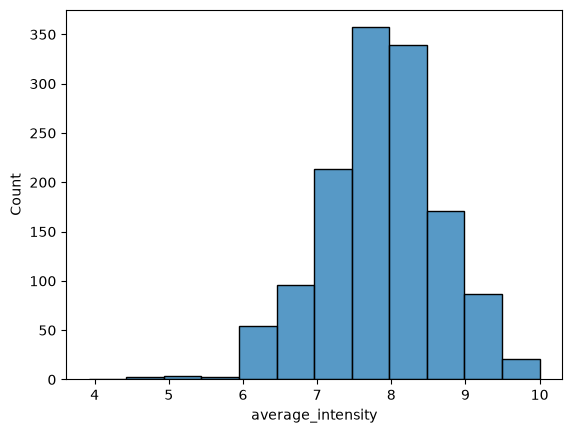

In [21]:
sns.histplot(data=df, x="average_intensity",binwidth=0.5)

<Axes: xlabel='average_intensity'>

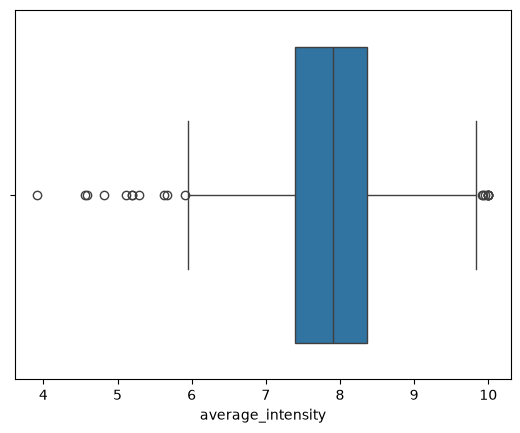

In [24]:
sns.boxplot(data=df, x="average_intensity")

## Reps

<Axes: xlabel='reps', ylabel='Count'>

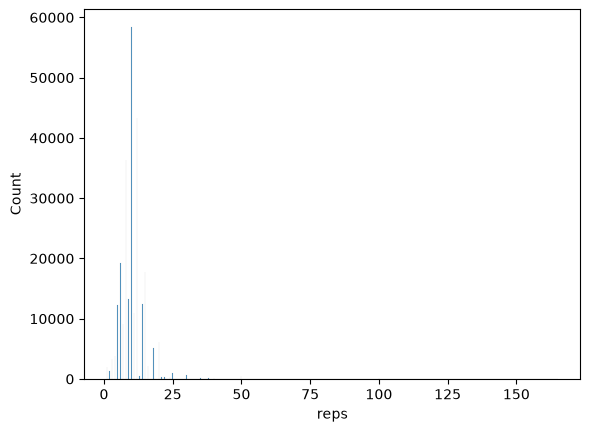

In [27]:
sns.histplot(data=ex, x="reps",)

<Axes: xlabel='reps'>

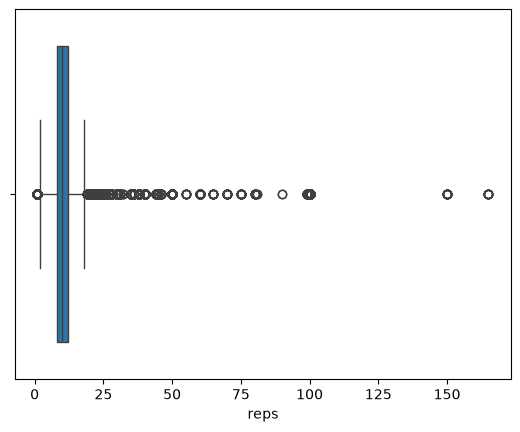

In [29]:
sns.boxplot(data=ex, x="reps",)

In [28]:
ex.reps.max()

np.int64(165)

In [26]:
ex.columns

Index(['title', 'description', 'level', 'goal', 'equipment', 'program_length',
       'time_per_workout', 'week', 'day', 'number_of_exercises',
       'exercise_name', 'sets', 'reps', 'intensity', 'exercise_label',
       'day_label'],
      dtype='str')

In [25]:
df.columns

Index(['title', 'description', 'level', 'goal', 'equipment',
       'program_length_weeks', 'time_per_workout', 'total_exercises',
       'program_length_days', 'average_intensity'],
      dtype='str')

In [30]:
sns.heatmap(df)

ValueError: could not convert string to float: 'nSuns_Rebuild by KSI'

In [31]:
df.head()

,title,description,level,goal,equipment,program_length_weeks,time_per_workout,total_exercises,program_length_days,average_intensity
0,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{Novice, Intermediate, Advanced, Beginner}","{Bodybuilding, Powerbuilding}",Full Gym,7,90,140,35,8.40
1,Rampage,Pack on muscle and gain strength through this ...,"{Intermediate, Advanced}","{Bodybuilding, Powerbuilding}",Full Gym,18,70,558,108,8.51
2,Fitness King Powerbuild 101,To gain strength while building aesthetic musc...,"{Intermediate, Advanced}","{Bodybuilding, Powerbuilding}",Full Gym,11,160,324,56,7.62
3,Larry's Modified Bullmastiff Powerbuilding Pro...,All credit to Alex. You can find his original ...,"{Novice, Intermediate, Beginner}","{Muscle & Sculpting, Powerbuilding, Powerlifti...",Full Gym,9,70,342,54,7.30
4,Metallicdpas PPL (Reddit),"Metallicdpas’ PPL targeted towards beginners, ...","{Novice, Intermediate, Beginner}","{Muscle & Sculpting, Athletics, Bodybuilding}",Garage Gym,6,60,216,36,7.72


In [32]:
sns.histplot(data=df, x='level', hue='goal', multiple = 'stack')

TypeError: unhashable type: 'set'

<Axes: xlabel='average_intensity', ylabel='Count'>

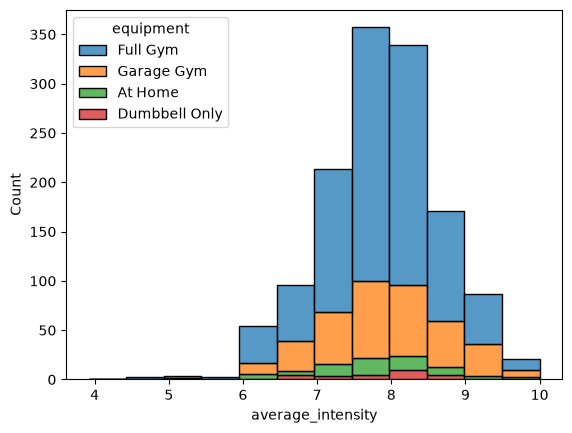

In [35]:
sns.histplot(data=df, x='average_intensity', hue='equipment', multiple = 'stack', binwidth=0.5)

<Axes: xlabel='average_intensity', ylabel='Density'>

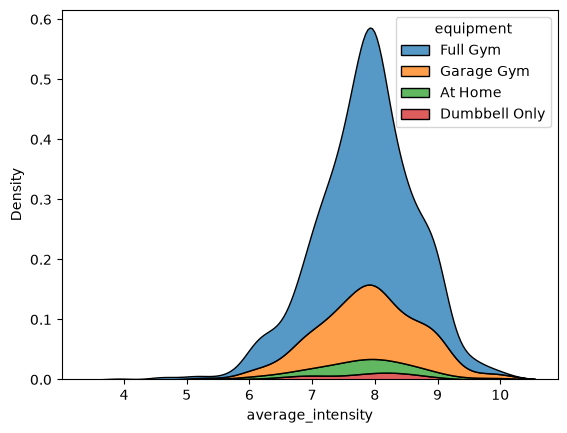

In [37]:
sns.kdeplot(data=df, x='average_intensity', hue='equipment', multiple = 'stack')

# Find level relationships

In [41]:
# def parse_set(s):
#     if pd.isna(s):
#         return []
#     try:
#         return sorted(ast.literal_eval(s))
#     except Exception:
#         return [x.strip(" '\"") for x in s.strip('{}').split(',') if x.strip()]
 
# df['level_list'] = df['level'].apply(parse_set)
# df['goal_list']  = df['goal'].apply(parse_set)
 
LEVEL_ORDER = ['Beginner', 'Novice', 'Intermediate', 'Advanced']   # assumed progression -- adjust if you have a canonical order
GOAL_ORDER  = df['goal'].explode().value_counts().index.tolist()  # descending frequency
 
# ---- cross-join level x goal per program (each program contributes to every combo it covers) ----
# combos = df[['title', 'level_list', 'goal_list']].explode('level_list').explode('goal_list').reset_index(drop=True)

In [43]:
GOAL_ORDER

['Bodybuilding',
 'Powerbuilding',
 'Muscle & Sculpting',
 'Athletics',
 'Powerlifting',
 'Bodyweight Fitness',
 'Olympic Weightlifting']

In [44]:
LEVEL_ORDER

['Beginner', 'Novice', 'Intermediate', 'Advanced']

In [48]:
combos = df[['title','level']].explode('level').reset_index(drop=True)

In [49]:
combos['level_list'] = combos.apply(

,title,level
0,nSuns_Rebuild by KSI,Novice
1,nSuns_Rebuild by KSI,Intermediate
2,nSuns_Rebuild by KSI,Advanced
3,nSuns_Rebuild by KSI,Beginner
4,Rampage,Intermediate
...,...,...
3431,3 Day Baki Grappler Condensed Conjugate (0),Beginner
3432,3 Day Baki Grappler Condensed Conjugate (1),Intermediate
3433,3 Day Baki Grappler Condensed Conjugate (1),Advanced
3434,3 Day Baki Grappler Condensed Conjugate (2),Intermediate


In [51]:
df[['title','level','level']]

,title,level,level
0,nSuns_Rebuild by KSI,"{Novice, Intermediate, Advanced, Beginner}","{Novice, Intermediate, Advanced, Beginner}"
1,Rampage,"{Intermediate, Advanced}","{Intermediate, Advanced}"
2,Fitness King Powerbuild 101,"{Intermediate, Advanced}","{Intermediate, Advanced}"
3,Larry's Modified Bullmastiff Powerbuilding Pro...,"{Novice, Intermediate, Beginner}","{Novice, Intermediate, Beginner}"
4,Metallicdpas PPL (Reddit),"{Novice, Intermediate, Beginner}","{Novice, Intermediate, Beginner}"
...,...,...,...
1355,PPL x Arnold (0),"{Novice, Intermediate}","{Novice, Intermediate}"
1356,PPL x Arnold (1),"{Novice, Intermediate, Advanced, Beginner}","{Novice, Intermediate, Advanced, Beginner}"
1357,3 Day Baki Grappler Condensed Conjugate (0),"{Novice, Beginner}","{Novice, Beginner}"
1358,3 Day Baki Grappler Condensed Conjugate (1),"{Intermediate, Advanced}","{Intermediate, Advanced}"
